# 1.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("~/shared/data/temperature.csv")


### (a)

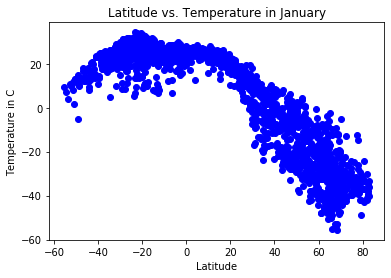

-0.8808243838931636


In [10]:
plt.scatter(df['latitude'], df['1'], color='blue')
plt.title('Latitude vs. Temperature in January')
plt.xlabel('Latitude')
plt.ylabel('Temperature in C')
plt.show()
january = df['latitude'].corr(df['1'])
print(january)

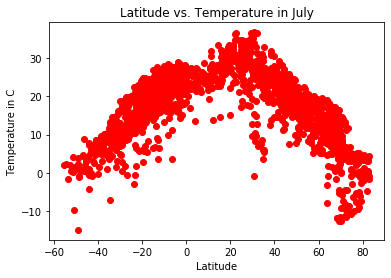

-0.09081110315246951


In [11]:
plt.scatter(df['latitude'], df['7'], color='red')
plt.title('Latitude vs. Temperature in July')
plt.xlabel('Latitude')
plt.ylabel('Temperature in C')
plt.show()
july = df['latitude'].corr(df['7'])
print(july)


### (b)

There is a natural justification for choosing the x-axis to represent latitude and the y-axis to represent temperature, because temperature is affected by the latitude due to its distance from the equator and other factors

### (c)

The correlation would not change if you changed the x and y-axis because correlation is symmetrical and measures the linear relationship between two different variables so it wouldn't matter what variable is in the x-axis and y-axis.

### (d)

In the January scatterplot, it shows a clear negative trend which means that temperatures decrease as the latitude increases. The correlation between latitude and temperature was calculated to be -0.88 which shows a strong negative correlation.

For July, the graph shows a much weaker negative trend and the correlation calculated is -0.009 which is a a weak negative correlation. This could mean that in July, temperatures are less affected by the latitude. This could be due to a number of issues, the main one being the seasonal difference between the hemispheres. 

### (e)

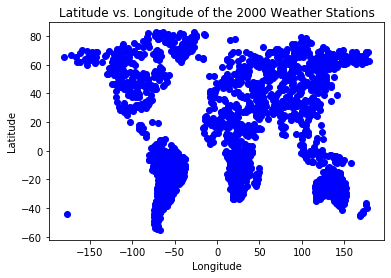

Min:  -55.25
Max:  82.75


In [12]:
plt.scatter(df['longitude'], df['latitude'])
plt.title('Latitude vs. Longitude of the 2000 Weather Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("Min: ", df['latitude'].min())
print("Max: ", df['latitude'].max())

Based on the plot, the distribution of the weather stations to don't appear to be a random sample of the Earth's surface, it has a bias for areas that are more populated and have developed infrastructure. Due of fewer date at the extreme southern latitudes this could effect the correlation because there are more weather stations in the mid/northern latitudes which could over represent the temperature and not capture the true global trends.

### (f)

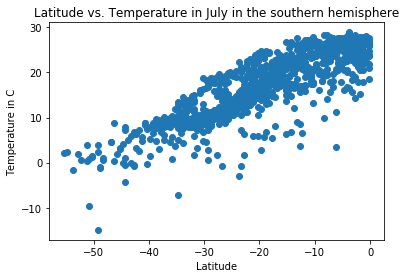

Southern Hemisphere correlation in July: 0.853957309343342


In [13]:
southern = df[df['latitude'] < 0]
plt.scatter(southern['latitude'], southern['7'])
plt.title('Latitude vs. Temperature in July in the southern hemisphere')
plt.xlabel('Latitude')
plt.ylabel('Temperature in C')
plt.show()
southern_corr = southern['latitude'].corr(southern['7'])
                                          
print("Southern Hemisphere correlation in July:", southern_corr)

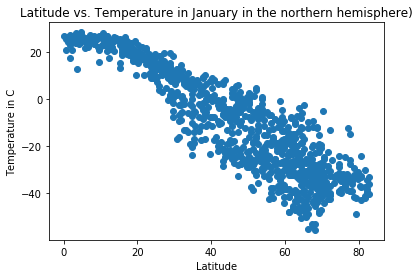

Northern Hemisphere correlation in January: -0.9044282825621139


In [14]:
northern = df[df['latitude'] > 0]
plt.scatter(northern['latitude'], northern['1'])
plt.title('Latitude vs. Temperature in January in the northern hemisphere)')
plt.xlabel('Latitude')
plt.ylabel('Temperature in C')
plt.show()
print("Northern Hemisphere correlation in January:", northern['latitude'].corr(northern['1']) )

### (g)

Based on my findings, the scatter plot shows a strong positive correlation at 0.85 for the southern hemisphere in July which could mean that that there are warmer temperatures as you get closer to the equator. In the northern hemisphere in January, it showed a strong negative correlation at -0.90 which means that the more north you go, the lower the temperature gets. Both graphs show that moving away from the equator leads to colder temperatures. 

### (h)

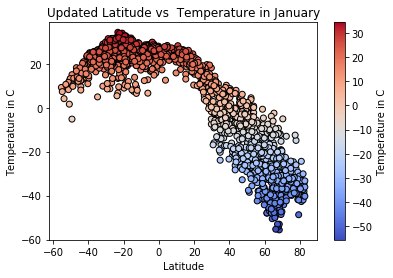

In [15]:
sc = plt.scatter(df['latitude'], df['1'], c=df['1'], cmap='coolwarm', edgecolor='k')
plt.colorbar(sc, label='Temperature in C')
plt.title('Updated Latitude vs  Temperature in January')
plt.xlabel('Latitude')
plt.ylabel('Temperature in C')
plt.show()

I added a gradient color to each of the data points to help show the temperature change and used the edge color to help the data pop out. I also add a bar on the side to help represent what each color means.

# 2.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("~/shared/data/momiq.csv")

### (a)

The formula for the slop of the regression line is:
ρ * (σx /σy)

### (b)

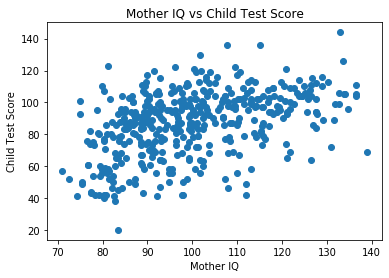

Correlation between Mothers IQ and Childs Test Score:  0.448275842265174


In [17]:
plt.scatter(df['mom_iq'], df['kid_score'])
plt.title('Mother IQ vs Child Test Score')
plt.xlabel('Mother IQ')
plt.ylabel('Child Test Score')
plt.show()
print("Correlation between Mothers IQ and Childs Test Score: ", df['mom_iq'].corr(df['kid_score']))

Based on the scatter plot and the correlation, there is a positive relationship between the variables with a correlation of 0.45, which means that generally the higher the IQ of the mother, the higher the child's test scores. I decided to use the mother's IQ as the x-axis and the child's test score as the y-axis because we want to understand how the mother's IQ can affect the child's scores.

### (c)

In [18]:
def standardize(column):
    mean = column.mean() #the mean
    std = column.std() #the standard deviation
    standardized = (column - mean) / std # find the standardized value
    return standardized

### (d)

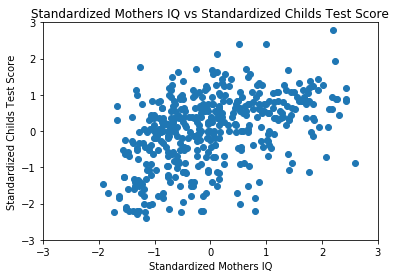

In [19]:
df['standardized_mom_iq'] = standardize(df['mom_iq'])
df['standardized_kid_score'] = standardize(df['kid_score'])


plt.scatter(df['standardized_mom_iq'], df['standardized_kid_score'])
plt.title('Standardized Mothers IQ vs Standardized Childs Test Score')
plt.xlabel('Standardized Mothers IQ')
plt.ylabel('Standardized Childs Test Score')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

The two graphs have a similar pattern, however, in the standardized graph, the mean is scaled to 0 and the standard deviation is scaled to 1. 

### (e)

In [20]:
import statsmodels.formula.api as smf

model = smf.ols('standardized_kid_score ~ standardized_mom_iq', data=df).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     standardized_kid_score   R-squared:                       0.201
Model:                                OLS   Adj. R-squared:                  0.199
Method:                     Least Squares   F-statistic:                     108.6
Date:                    Mon, 04 Nov 2024   Prob (F-statistic):           7.66e-23
Time:                            23:54:31   Log-Likelihood:                -566.64
No. Observations:                     434   AIC:                             1137.
Df Residuals:                         432   BIC:                             1145.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

### (f)

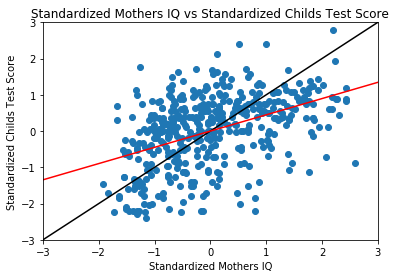

In [21]:
import numpy as np
plt.scatter(df['standardized_mom_iq'], df['standardized_kid_score'])

plt.plot([-3, 3], [-3, 3], color='black', linestyle='-', label='Y = X')



intercept = model.params['Intercept']
slope = model.params['standardized_mom_iq']
x_values = np.array([-3, 3])
y_values = intercept + slope * x_values
plt.plot(x_values, y_values, color='red', linestyle='-')

plt.title('Standardized Mothers IQ vs Standardized Childs Test Score')
plt.xlabel('Standardized Mothers IQ')
plt.ylabel('Standardized Childs Test Score')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

### (g)

The regression line fits the data better than the Y = X line. The Y = X line assumes that there is a perfect relationship between the mothers IQ and child's test scores. But, the regression line shows that relationship between the mothers IQ and child's test scores are positive but not perfectly accurate. 

# 3.

### (a)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("~/shared/data/bread_votes.csv")

mean_recent_growth = df['avg_recent_growth'].mean()
std_recent_growth = df['avg_recent_growth'].std()

print("Mean: ", mean_recent_growth)
print("Standard deviation: ", std_recent_growth)
print("Number of observations: ", len(df))

Mean:  2.4977206998443435
Standard deviation:  1.394685486217887
Number of observations:  19


### (b)

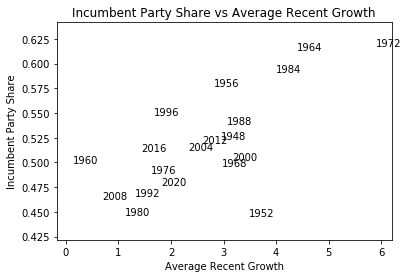

In [23]:
plt.scatter(df['avg_recent_growth'], df['incumbent_party_share'], color='white')

for index, row in df.iterrows():
   
    plt.text(row['avg_recent_growth'], row['incumbent_party_share'], str(row['year']))


plt.xlabel('Average Recent Growth')
plt.ylabel('Incumbent Party Share')
plt.title('Incumbent Party Share vs Average Recent Growth')


plt.show()

### (c)

In [24]:
print("Correlation: ", df['avg_recent_growth'].corr(df['incumbent_party_share']))

Correlation:  0.6972418358586795


The result of the correlation shows a positive correlation where as the average recent growth increases, the incumbent party share also for the most part increase. After a term with a significantly higher than average growth in personal income, the incumbent party tends to see an increase in vote share, this could be because people will associate economic growth with the policies of the incumbent party, so they will support the incumbent due to this. 

### (d)

In [33]:
#incumbent_party_share is the dependent variable, avg_recent_growth is the independent variable
model = smf.ols('incumbent_party_share ~ avg_recent_growth', data=df).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     incumbent_party_share   R-squared:                       0.486
Model:                               OLS   Adj. R-squared:                  0.456
Method:                    Least Squares   F-statistic:                     16.08
Date:                   Tue, 05 Nov 2024   Prob (F-statistic):           0.000907
Time:                           00:09:06   Log-Likelihood:                 35.970
No. Observations:                     19   AIC:                            -67.94
Df Residuals:                         17   BIC:                            -66.05
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercep

The intercept shows the predicted incumbent party's vote when the average recent growth is 0, for the data, the intercept is 0.4526 which mean that if there is no recent growth, the incumbent part is expected to get 45.26% of the votes. In terms of the slope, it shows the change in the party's voting share as the recent growth increases. The slope if 0.0261 which means that as the average recent growth increases but 1%, the incumbent party's vote char will increase by 2.61.

### (e)

In [34]:

avg_recent_growth_2024 = 2.47
predicted_vote_share_2024 = model.params['Intercept'] + model.params['avg_recent_growth'] * avg_recent_growth_2024
print("Incumbent party's popular vote share in 2024: ", predicted_vote_share_2024)



Incumbent party's popular vote share in 2024:  0.5171393624426903


### (f)

In [35]:


new_pred = model.params['Intercept'] + model.params['avg_recent_growth'] * avg_recent_growth_2024  
#Calculate s 
n = len(df)
s = np.sqrt(sum(model.resid**2) / (n - 2))

#Find the mean of avg_recent_growth and sum of squared deviations 
sum_squared_deviations = sum((df['avg_recent_growth'] - df['avg_recent_growth'].mean()) ** 2)

#Findthe standard error of the prediction
SE_pred = s * np.sqrt(1 + (1 / n) + ((2.47 - df['avg_recent_growth'].mean()) ** 2) / sum_squared_deviations)

# Find the confidence interval
lower_bound = new_pred - 2 * SE_pred
upper_bound = new_pred + 2 * SE_pred

#round to two decimal points
lower_bound_rounded = round(lower_bound, 2)
upper_bound_rounded = round(upper_bound, 2)
SE_pred_rounded = round(SE_pred, 2)

print("Standard Error: ", SE_pred_rounded, "Lower Bound: ", lower_bound_rounded, "Upper Bound: ", upper_bound_rounded)




Standard Error:  0.04 Lower Bound:  0.44 Upper Bound:  0.6
